# Example 9: Regularisation

This example shows one of the simplest ways to improve the robustness of portfolios, regularisation penalties.

In [1]:
using PortfolioOptimisers, PrettyTables
# Format for pretty tables.
tsfmt = (v, i, j) -> begin
    if j == 1
        return Date(v)
    else
        return v
    end
end;
resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=3)) %" : v
    end
end;
mmtfmt = (v, i, j) -> begin
    if i == j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=3)) %" : v
    end
end;
summary_row = (data, j) -> begin
    if j == 1
        return "N/A"
    else
        return number_effective_assets(data[:, j])
    end
end

#11 (generic function with 1 method)

## 1. Setting up

We will use the same data as the previous example.

In [2]:
using CSV, TimeSeries, DataFrames, Clarabel

X = TimeArray(CSV.File(joinpath(@__DIR__, "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
pretty_table(X[(end - 5):end]; formatters = [tsfmt])

# Compute the returns
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)

slv = [Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel2, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.95),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel3, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.9),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel4, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.85),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel5, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.8),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel6, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.75),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel7, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.70),
              check_sol = (; allow_local = true, allow_almost = true))];

┌────────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬──────
│  timestamp │    AAPL │     AMD │     BAC │     BBY │     CVX │      GE │     ⋯
│       Date │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │ Flo ⋯
├────────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼──────
│ 2022-12-20 │ 131.916 │   65.05 │  31.729 │  77.371 │ 169.497 │  62.604 │ 310 ⋯
│ 2022-12-21 │ 135.057 │   67.68 │  32.212 │  78.729 │  171.49 │   64.67 │ 314 ⋯
│ 2022-12-22 │ 131.846 │   63.86 │  31.927 │  78.563 │ 168.918 │  63.727 │ 311 ⋯
│ 2022-12-23 │ 131.477 │   64.52 │  32.005 │  79.432 │  174.14 │  63.742 │ 314 ⋯
│ 2022-12-27 │ 129.652 │   63.27 │  32.065 │   79.93 │ 176.329 │  64.561 │ 314 ⋯
│ 2022-12-28 │ 125.674 │   62.57 │  32.301 │  78.279 │ 173.728 │  63.883 │  31 ⋯
└────────────┴─────────┴─────────┴─────────┴─────────┴─────────┴─────────┴──────
                                                              14 columns omitted


## 2. Regularised portfolios

The optimal regularisation penalty value depends on the data, the investor preferences, and type of regularisation. The specific choice of penalty value is so volatile that it can only be estimated via grid search cross-validation or similar techniques, but the "optimal" (to some definition of optimal) value will also change over time as the market conditions change. Therefore, we will simply show how to set up and solve a regularised portfolio optimisation problem, without attempting to find the optimal penalty value.

We will use the same small penalty for all regularisations to illustrate how they differ.

  - L1 regularisation (also known as Lasso regularisation) adds a penalty proportional to the sum of the absolute values of the portfolio weights. This encourages sparsity in the portfolio, leading to fewer assets being selected.
  - L2 regularisation (also known as Ridge regularisation) adds a penalty proportional to the sum of the squares of the portfolio weights. This discourages large weights and promotes diversification.
  - Lp regularisation via [`LpRegularisation`]-(@ref) adds a penalty proportional to the p-norm of the portfolio weights, where `p > 1` is a positive real number.
  - L-Inf regularisation adds a penalty proportional to the maximum absolute value of the portfolio weights. This limits the influence of any single asset in the portfolio.

### 2.1 Efficient frontier

In [3]:
opts = [JuMPOptimiser(; pe = pr, slv = slv, wb = WeightBounds(; lb = -1, ub = 1), sbgt = 1,
                      bgt = 1, ret = ArithmeticReturn(; lb = Frontier(; N = 50))),#
        JuMPOptimiser(; pe = pr, slv = slv, wb = WeightBounds(; lb = -1, ub = 1), sbgt = 1,
                      ret = ArithmeticReturn(; lb = Frontier(; N = 50)), bgt = 1,
                      l1 = 4e-4),#
        JuMPOptimiser(; pe = pr, slv = slv, wb = WeightBounds(; lb = -1, ub = 1), sbgt = 1,
                      ret = ArithmeticReturn(; lb = Frontier(; N = 50)), bgt = 1,
                      l2 = 4e-4),#
        JuMPOptimiser(; pe = pr, slv = slv, wb = WeightBounds(; lb = -1, ub = 1), sbgt = 1,
                      ret = ArithmeticReturn(; lb = Frontier(; N = 50)), bgt = 1,
                      lp = LpRegularisation(; p = 5, val = 4e-4)),#
        JuMPOptimiser(; pe = pr, slv = slv, wb = WeightBounds(; lb = -1, ub = 1), sbgt = 1,
                      ret = ArithmeticReturn(; lb = Frontier(; N = 50)), bgt = 1,
                      linf = 4e-4)]
nocs = [MeanRisk(; opt = opt) for opt in opts]
ress = optimise.(nocs)

5-element Vector{MeanRiskResult{DataType, ProcessedJuMPOptimiserAttributes{LowOrderPrior{Matrix{Float64}, Vector{Float64}, Matrix{Float64}, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing}, WeightBounds{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}}, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, ArithmeticReturn{Nothing, Frontier{Int64, Int64, Bool}, Vector{Float64}}}, Vector{OptimisationReturnCode}, Vector{JuMPOptimisationSolution}, JuMP.Model, Nothing}}:
 MeanRiskResult
       oe ┼ DataType: DataType
       pa ┼ ProcessedJuMPOptimiserAttributes
          │        pr ┼ LowOrderPrior
          │           │         X ┼ 252×20 Matrix{Float64}
          │           │        mu ┼ 20-element Vector{Float64}
          │           │     sigma

Let's plot the efficient frontiers.

In [4]:
using StatsPlots, GraphRecipes

r = Variance()

Variance
  settings ┼ RiskMeasureSettings
           │   scale ┼ Float64: 1.0
           │      ub ┼ nothing
           │     rke ┴ Bool: true
     sigma ┼ nothing
      chol ┼ nothing
        rc ┼ nothing
       alg ┴ SquaredSOCRiskExpr()


No regularisation portfolio weights.

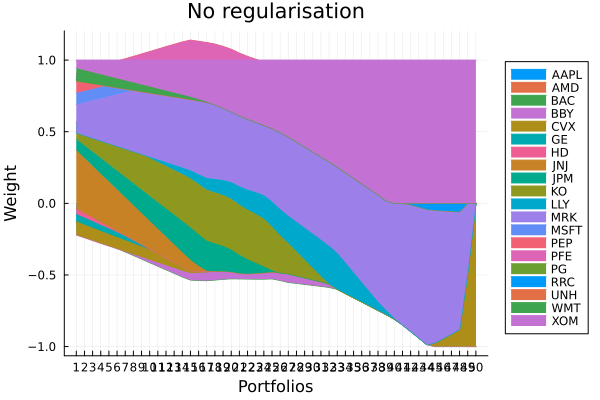

In [5]:
plot_stacked_area_composition(ress[1].w, rd.nx;
                              kwargs = (; xlabel = "Portfolios", ylabel = "Weight",
                                        title = "No regularisation", legend = :outerright))

No regularisation frontier.

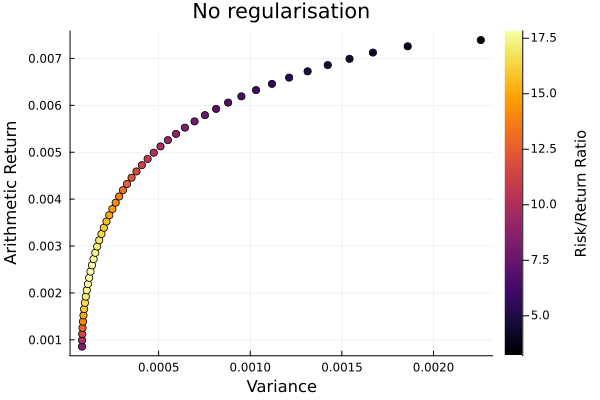

In [6]:
plot_measures(ress[1].w, pr; x = r, y = ExpectedReturn(; rt = ress[1].ret),
              c = ExpectedReturnRiskRatio(; rt = ress[1].ret, rk = r, rf = 4.2 / 100 / 252),
              title = "No regularisation", xlabel = "Variance",
              ylabel = "Arithmetic Return", colorbar_title = "\nRisk/Return Ratio",
              right_margin = 6Plots.mm)

L1 regularisation portfolio weights. As expected, the portfolio is sparsified, with fewer assets with non-zero weight.

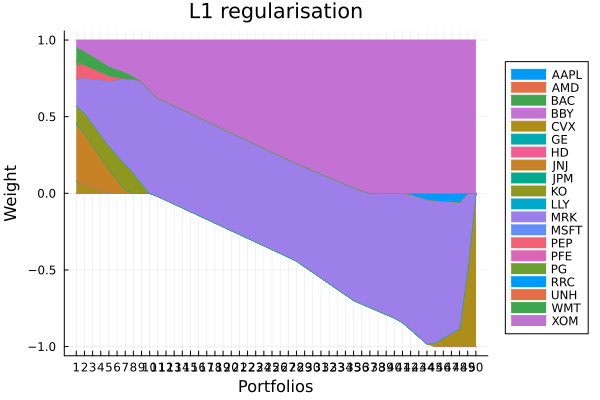

In [7]:
plot_stacked_area_composition(ress[2].w, rd.nx;
                              kwargs = (; xlabel = "Portfolios", ylabel = "Weight",
                                        title = "L1 regularisation", legend = :outerright))

L1 regularisation frontier. The sparsification makes the pareto front non-smooth.

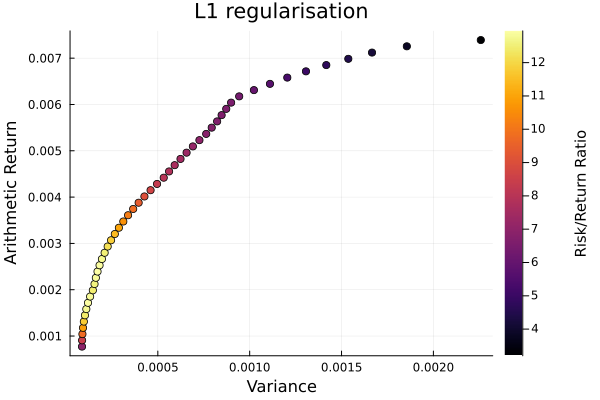

In [8]:
plot_measures(ress[2].w, pr; x = r, y = ExpectedReturn(; rt = ress[2].ret),
              c = ExpectedReturnRiskRatio(; rt = ress[1].ret, rk = r, rf = 4.2 / 100 / 252),
              title = "L1 regularisation", xlabel = "Variance",
              ylabel = "Arithmetic Return", colorbar_title = "\nRisk/Return Ratio",
              right_margin = 6Plots.mm)

L2 regularisation portfolio weights. Even values of p-norms smooth out the weights, leading to more diversified portfolios. The higher the value, the more highly penalised larger deviations from the mean weight become. This is similar to how moments of even order behave.

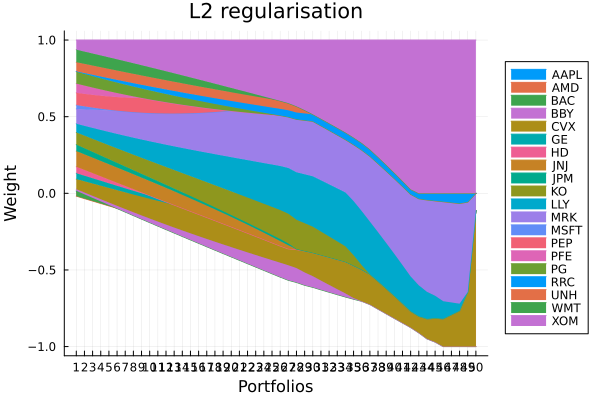

In [9]:
plot_stacked_area_composition(ress[3].w, rd.nx;
                              kwargs = (; xlabel = "Portfolios", ylabel = "Weight",
                                        title = "L2 regularisation", legend = :outerright))

L2 regularisation frontier.

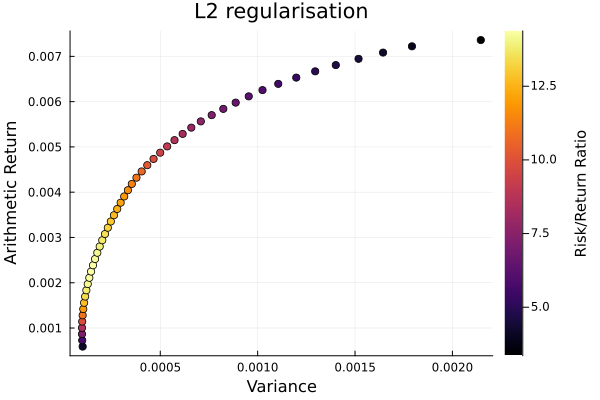

In [10]:
plot_measures(ress[3].w, pr; x = r, y = ExpectedReturn(; rt = ress[3].ret),
              c = ExpectedReturnRiskRatio(; rt = ress[1].ret, rk = r, rf = 4.2 / 100 / 252),
              title = "L2 regularisation", xlabel = "Variance",
              ylabel = "Arithmetic Return", colorbar_title = "\nRisk/Return Ratio",
              right_margin = 6Plots.mm)

Lp regularisation portfolio weights. The higher the value of p, the closer the behaviour is to L-Inf regularisation, where the maximum absolute weight is penalised. This leads to portfolios where all weights are more similar in magnitude, but does not smear the negative weights into positive values like the L2 norm.

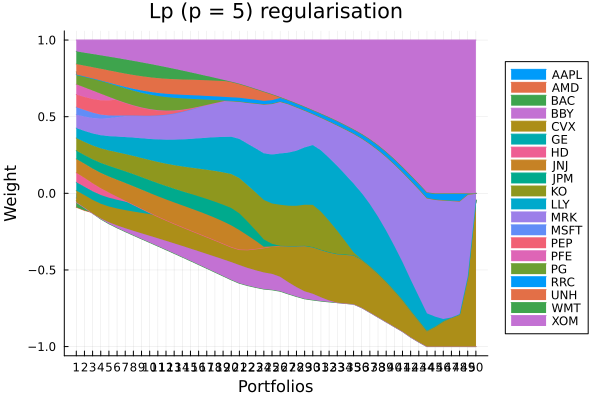

In [11]:
plot_stacked_area_composition(ress[4].w, rd.nx;
                              kwargs = (; xlabel = "Portfolios", ylabel = "Weight",
                                        title = "Lp (p = 5) regularisation",
                                        legend = :outerright))

Lp regularisation frontier.

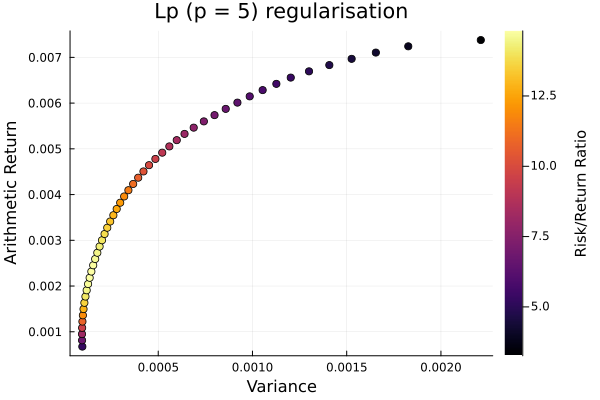

In [12]:
plot_measures(ress[4].w, pr; x = r, y = ExpectedReturn(; rt = ress[4].ret),
              c = ExpectedReturnRiskRatio(; rt = ress[1].ret, rk = r, rf = 4.2 / 100 / 252),
              title = "Lp (p = 5) regularisation", xlabel = "Variance",
              ylabel = "Arithmetic Return", colorbar_title = "\nRisk/Return Ratio",
              right_margin = 6Plots.mm)

L-Inf regularisation portfolio weights.

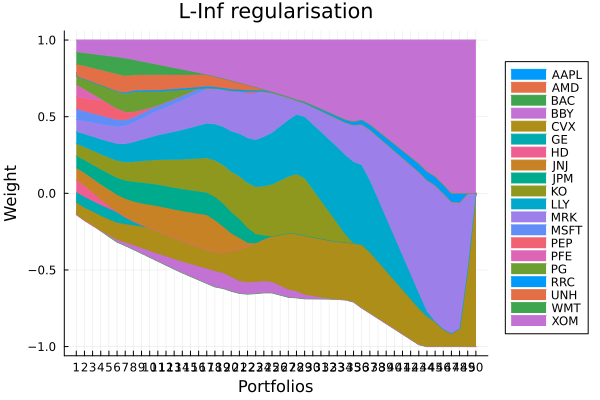

In [13]:
plot_stacked_area_composition(ress[5].w, rd.nx;
                              kwargs = (; xlabel = "Portfolios", ylabel = "Weight",
                                        title = "L-Inf regularisation",
                                        legend = :outerright))

L-Inf regularisation frontier.

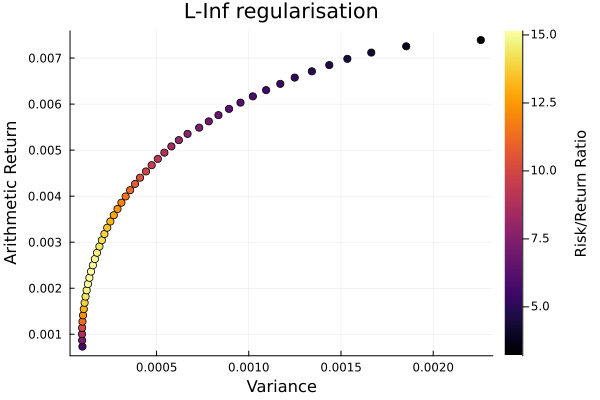

In [14]:
plot_measures(ress[5].w, pr; x = r, y = ExpectedReturn(; rt = ress[5].ret),
              c = ExpectedReturnRiskRatio(; rt = ress[1].ret, rk = r, rf = 4.2 / 100 / 252),
              title = "L-Inf regularisation", xlabel = "Variance",
              ylabel = "Arithmetic Return", colorbar_title = "\nRisk/Return Ratio",
              right_margin = 6Plots.mm)

### 2.2 Minimum risk portfolios

Lets view only the minimum risk portfolios for each regularisation to get more insight into what regularisation does.

In [15]:
opts = [JuMPOptimiser(; pe = pr, slv = slv, wb = WeightBounds(; lb = -1, ub = 1), sbgt = 1,
                      bgt = 1),# no regularisation
        JuMPOptimiser(; pe = pr, slv = slv, wb = WeightBounds(; lb = -1, ub = 1), sbgt = 1,
                      bgt = 1, l1 = 4e-4),# L1 regularisation
        JuMPOptimiser(; pe = pr, slv = slv, wb = WeightBounds(; lb = -1, ub = 1), sbgt = 1,
                      bgt = 1, l2 = 4e-4),# L2 regularisation
        JuMPOptimiser(; pe = pr, slv = slv, wb = WeightBounds(; lb = -1, ub = 1), sbgt = 1,
                      bgt = 1, lp = LpRegularisation(; p = 5, val = 4e-4)),# Lp regularisation with p = 5
        JuMPOptimiser(; pe = pr, slv = slv, wb = WeightBounds(; lb = -1, ub = 1), sbgt = 1,
                      bgt = 1, linf = 4e-4)]# L-Inf regularisation
nocs = [MeanRisk(; opt = opt) for opt in opts]

ress = optimise.(nocs)
pretty_table(DataFrame(:Assets => rd.nx, :No_Reg => ress[1].w, :L1 => ress[2].w,
                       :L2 => ress[3].w, :L5 => ress[4].w, :LInf => ress[5].w);
             formatters = [resfmt], summary_rows = [summary_row],
             summary_row_labels = ["# Eff. Assets"])

┌───────────────┬────────┬───────────┬──────────┬──────────┬──────────┬─────────
│               │ Assets │    No_Reg │       L1 │       L2 │       L5 │     LI ⋯
│               │ String │   Float64 │  Float64 │  Float64 │  Float64 │  Float ⋯
├───────────────┼────────┼───────────┼──────────┼──────────┼──────────┼─────────
│               │   AAPL │ -11.866 % │    0.0 % │  1.136 % │ -3.026 % │ -5.751 ⋯
│               │    AMD │   -1.55 % │    0.0 % │ -2.963 % │ -6.029 % │ -7.437 ⋯
│               │    BAC │   -5.46 % │    0.0 % │  3.488 % │   4.28 % │  1.181 ⋯
│               │    BBY │  -3.234 % │    0.0 % │  1.035 % │ -1.015 % │ -1.935 ⋯
│               │    CVX │   9.487 % │  7.415 % │   6.57 % │  7.554 % │  7.879 ⋯
│               │     GE │   5.203 % │  0.823 % │  3.871 % │  5.501 % │  6.838 ⋯
│               │     HD │   3.621 % │    0.0 % │  4.194 % │  6.143 % │  7.879 ⋯
│               │    JNJ │  40.958 % │ 36.981 % │ 10.221 % │   9.02 % │  7.879 ⋯
│               │    JPM │  

The effect of each regularisation depends on the relative values of the objective function with respect to the value of the relevant norm of the optimised portfolio weights multiplied by the penalty.

Generally, regularised portfolios tend to have more effective assets than unregularised ones. The number of effective assets is different to the sparsity in that it measures the concentration of weights as `1/(w ⋅ w)`, rather than counting the number of non-zero (or near zero) weights. Usually, the larger the number of effective assets, the more diversified the portfolio. Sparsity is a non-smooth measure, while the number of effective assets is smooth, so a portfolio can have higher sparsity and still have a larger number of effective assets.

It is possible to combine multiple regularisation penalties in the same optimisation problem by simultaneously specifying multiple regularisation keywords in the `JuMPOptimiser`. This can be useful to combine the benefits of different regularisations, such as sparsity and diversification, but can make the optimisation more difficult to solve and interpret.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*